# Telecom Monthly Network KPIs: Data Usage Bars with ARPU and Churn Lines (PROC GBARLINE)

## Executive Summary

This notebook uses **PROC GBARLINE** to combine a vertical bar chart of monthly mobile data usage with overlaid line plots of ARPU, churn, and support tickets — the classic "two-axis" KPI dashboard a telecom analyst builds to spot whether rising usage actually translates into revenue and retention. It generates synthetic per-subscriber records inline, then exercises the BAR and LINE statements with subgroups, custom right axes, reference symbols, and legends.

## Data Sources

**Dataset: `telco_kpi`** — synthetic per-subscriber-month records (4 months x 3 plan tiers x 8 subscribers = 96 rows), generated inline with `call streaminit(20260531)`. The panel is kept at 96 rows so it fits comfortably within the 100-observation limit of unlicensed mode, leaving every month and plan tier fully populated.

| Variable | Type | Description |
|----------|------|-------------|
| `month`  | Char | Calendar month label (Jan–Apr) |
| `plan`   | Char | Plan tier: Prepaid, Postpaid, Family |
| `data_gb`| Num  | Monthly mobile data consumed, in GB (gamma-distributed, with a gentle seasonal lift and slow growth) |
| `arpu`   | Num  | Average revenue per user, in USD (rises with plan tier and over the months) |
| `churn`  | Num  | Monthly churn flag (0/1, Bernoulli; higher early in the period and on lower tiers) |
| `tickets`| Num  | Support tickets opened (Poisson count) |

# Telecom Monthly Network KPIs with PROC GBARLINE

Telecom operators live and die by a handful of monthly KPIs: how much **data** subscribers consume, the **ARPU** (average revenue per user) that consumption generates, how many customers **churn**, and the **support-ticket** load behind it all. These metrics live on very different scales — gigabytes, dollars, and small counts — so plotting them on a single response axis hides the story.

`PROC GBARLINE` is built for exactly this: it draws a vertical **bar** chart against the left axis and overlays one or more **line** plots against an independent right axis. In this notebook we build a usage-vs-revenue dashboard, then progressively layer in plan-level subgroups, a custom right axis, and multi-line overlays.

## Step 1 — Generate synthetic subscriber-month data

The DATA step below fabricates a realistic panel: 4 months (Jan–Apr) across 3 plan tiers (Prepaid, Postpaid, Family) with 8 subscribers each, for 96 rows in all. We seed the RNG with `call streaminit` for reproducibility and draw each KPI from a domain-appropriate distribution:

- **Data usage** from a gamma distribution with a gentle seasonal lift and slow month-over-month growth.
- **ARPU** rising with plan tier and over the months, with normal noise.
- **Churn** as a Bernoulli flag that is higher early in the period and on cheaper tiers.
- **Support tickets** as Poisson counts, slightly heavier early on.

No external files are read — everything is self-contained, and the 96-row panel stays within the unlicensed 100-observation cap so every month and tier renders.

In [1]:
data telco_kpi;
    call streaminit(20260531);
    length month $3 plan $8;
    array mname[4] $3 _temporary_
        ('Jan' 'Feb' 'Mar' 'Apr');
    do mi = 1 to 4;
        month = mname[mi];
        /* gentle seasonal lift and slow data growth */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        do plan_i = 1 to 3;
            if plan_i = 1 then plan = 'Prepaid';
            else if plan_i = 2 then plan = 'Postpaid';
            else plan = 'Family';
            do rep = 1 to 8;
                /* monthly mobile data consumed (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* average revenue per user ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* monthly churn flag, higher early in year */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* support tickets opened */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                output;
            end;
        end;
    end;
    drop mi plan_i rep season mname:;
run;

NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — The core dashboard: usage bars + ARPU line

This is the canonical `GBARLINE` pattern. The `BAR` statement charts mean monthly data usage (`SUMVAR=data_gb TYPE=mean`), and a single `LINE` statement overlays mean ARPU on the right axis (`STAT=mean TYPE=join`). We turn on ODS Graphics and give the chart a two-line title. `COUTLINE=` and `WIDTH=` tidy up the bars.

                                           Monthly Mobile Data Usage and ARPU                                           
                                             Synthetic telecom network KPIs                                             



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Monthly Mobile Data Usage and ARPU.
NOTE: Option TITLE2 changed to Synthetic telecom network KPIs.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


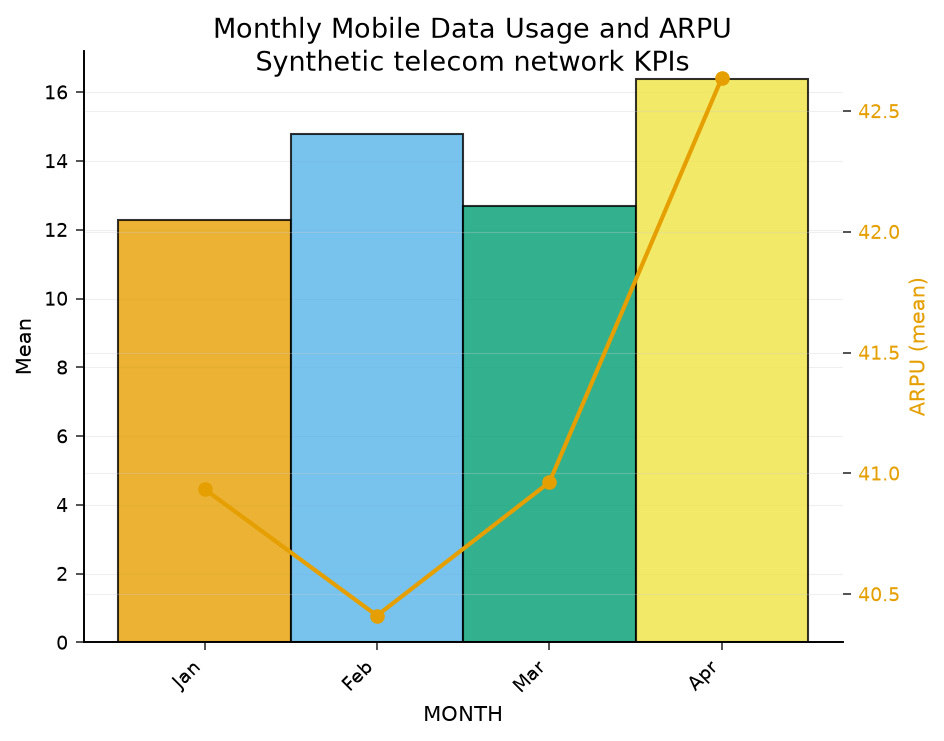

In [2]:
ods graphics on;
title 'Monthly Mobile Data Usage and ARPU';
title2 'Synthetic telecom network KPIs';

proc gbarline data=telco_kpi;
    bar month / sumvar=data_gb type=mean
                coutline=black width=6;
    line arpu / stat=mean type=join;
run;

## Step 3 — Break usage out by plan, overlay churn

Replacing `TYPE=mean` with `TYPE=sum` and adding `SUBGROUP=plan` stacks each month's bar by plan tier, so we can see which segment drives total volume. The overlaid `LINE` now plots the monthly **count** of churn events as a needle plot (`STAT=sum TYPE=needle`) — vertical spikes that read naturally as discrete event counts rather than a smooth trend.

                                         Data Volume by Plan with Monthly Churn                                         
                                             Synthetic telecom network KPIs                                             



NOTE: Option TITLE changed to Data Volume by Plan with Monthly Churn.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


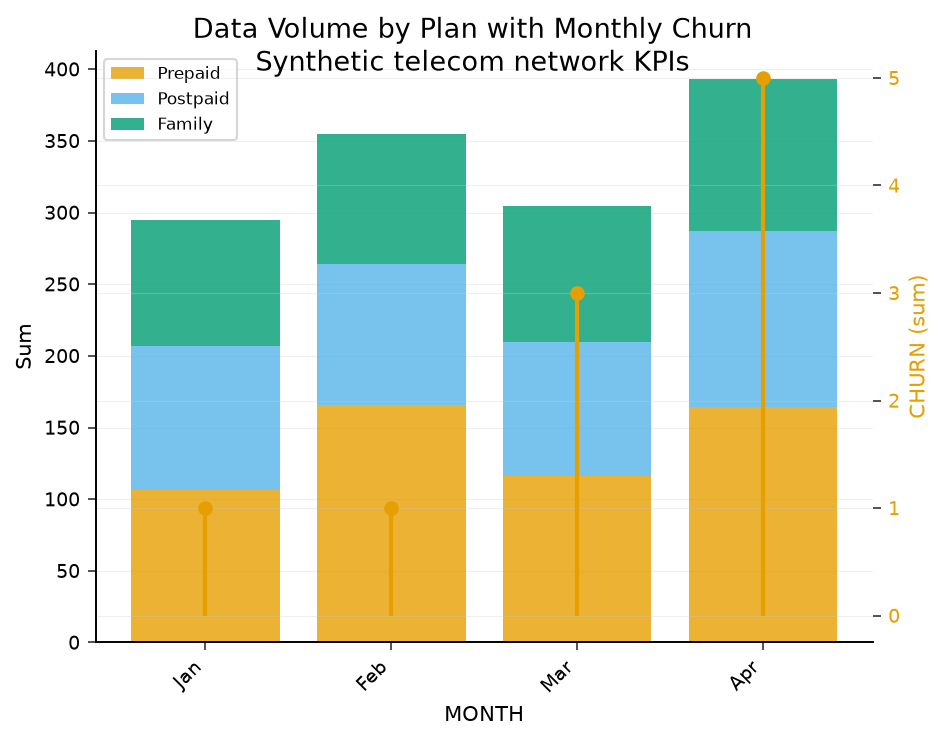

In [3]:
title 'Data Volume by Plan with Monthly Churn';

proc gbarline data=telco_kpi;
    bar month / sumvar=data_gb type=sum subgroup=plan;
    line churn / stat=sum type=needle;
run;

## Step 4 — Control the right axis and the line marker

For a publication-ready chart we pin the plot (right) axis to a fixed range with an `AXIS` definition and label it, then bind it to the line via `RAXIS=axis2`. A `SYMBOL` definition gives the ARPU line a red dotted marker. We also display the bar totals above each bar with `OUTSIDE=sum`.

                                         Total Usage (bars) vs Mean ARPU (line)                                         
                                             Synthetic telecom network KPIs                                             



NOTE: Option TITLE changed to Total Usage (bars) vs Mean ARPU (line).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


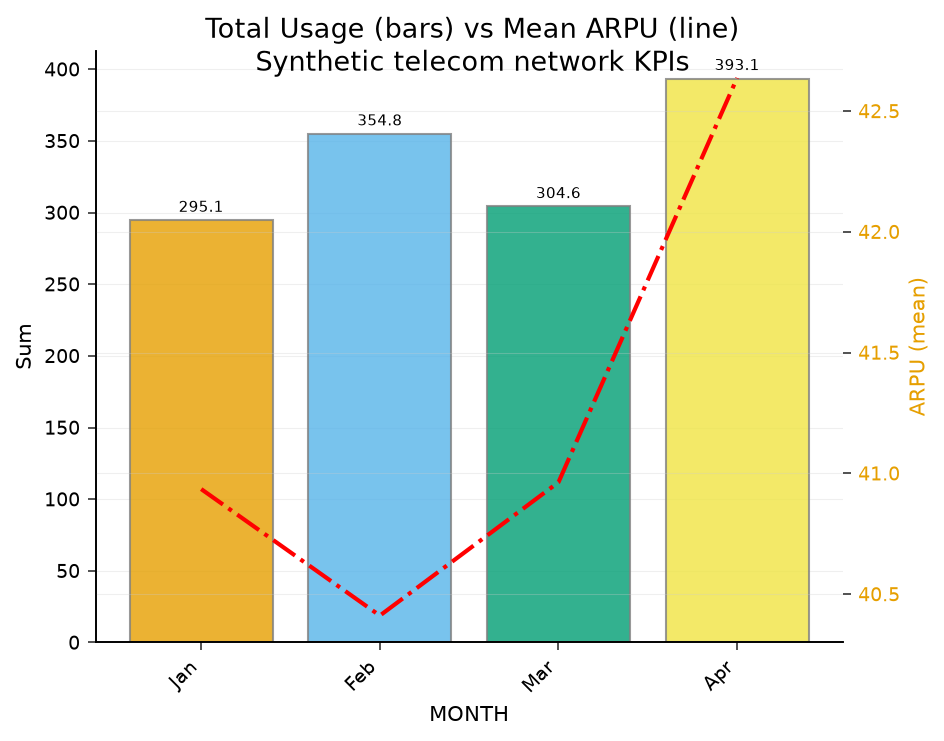

In [4]:
title 'Total Usage (bars) vs Mean ARPU (line)';

proc gbarline data=telco_kpi;
    axis2 order=(20 to 60 by 10) label=('Mean ARPU ($)');
    symbol1 color=red interpol=join value=dot height=1.4;
    bar month / sumvar=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / stat=mean type=join raxis=axis2 symbol=symbol1;
run;

## Step 5 — Multiple line overlays with a custom legend

`GBARLINE` accepts more than one `LINE` statement, so we can compare two operational signals against the usage bars at once: mean support tickets (`type=join`) and total churn (`type=needle`). A `LEGEND` definition positioned at the bottom documents the plan subgroups.

                                            Support Tickets and Churn Trends                                            
                                             Synthetic telecom network KPIs                                             



NOTE: Option TITLE changed to Support Tickets and Churn Trends.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


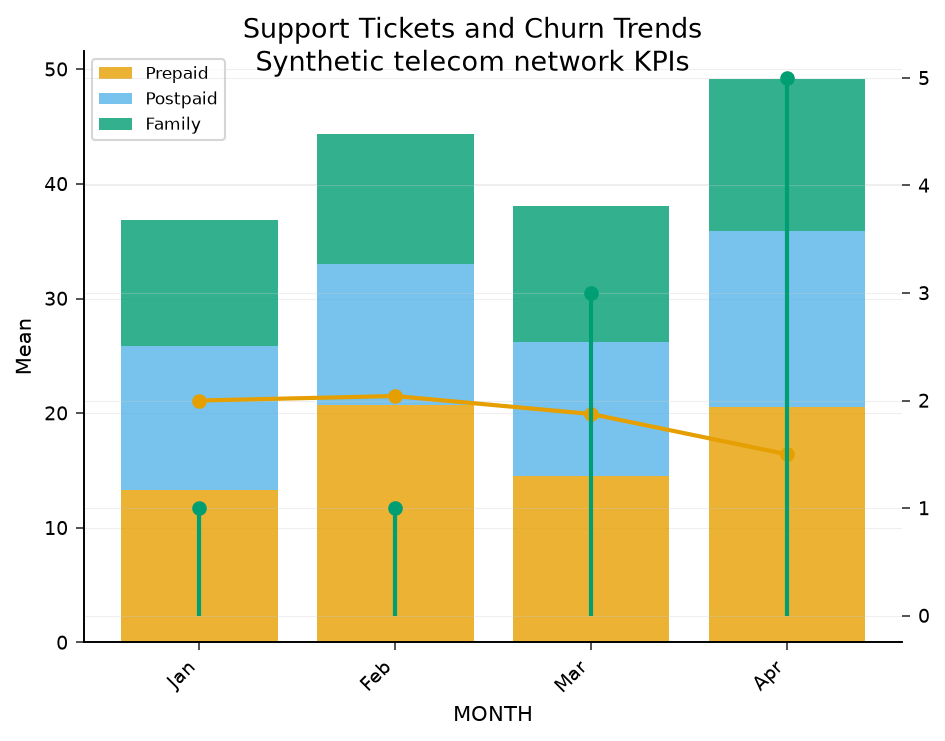

In [5]:
title 'Support Tickets and Churn Trends';

proc gbarline data=telco_kpi;
    legend1 label=('Plan') position=(bottom) across=3;
    bar month / sumvar=data_gb type=mean subgroup=plan
                legend=legend1;
    line tickets / stat=mean type=join;
    line churn / stat=sum type=needle;
run;

ods graphics off;

## Interpreting the results

Across the Jan–Apr window the dashboard tells a coherent telecom story. **Data usage** (the bars) is choppy month to month but trends upward, peaking in **April** — mean usage climbs from about 12.3 GB in January to 16.4 GB in April (Step 2), and total volume from 295 GB to 393 GB (the `OUTSIDE=sum` labels in Step 4). The **ARPU line** dips slightly in February and then climbs to its own April high near \$42.6, so the operator is increasingly monetizing the extra consumption rather than giving it away — the right axis in Step 4 is pinned to \$20–\$60 to keep that movement readable.

The plan-stacked views (Steps 3 and 5) reveal the segment tension that defines prepaid-heavy carriers. **Prepaid** (the orange band) carries the most gigabytes overall — roughly 553 GB across the four months versus 415 GB for Postpaid and 380 GB for Family — yet it earns the **lowest** average revenue per user (about \$36, against \$41 for Postpaid and \$47 for Family). The **churn needles** confirm where the retention risk sits: churn events cluster on the Prepaid and Postpaid tiers (4 events each over the window) and stay lighter on Family (2), and they grow toward April as the subscriber base and usage expand.

Step 5 overlays the operational load on top of this: mean **support tickets** run a touch heavier early in the period and ease off by April, while the churn needles peak later — the kind of signal a retention team watches for. Operationally, the read is to concentrate retention spend on **Prepaid** subscribers, who consume the fastest-growing slice of data volume while generating the least revenue and the most churn.

`PROC GBARLINE` is the right tool here precisely because it keeps the gigabyte-scale bars and the dollar/count-scale lines on independent axes, letting each KPI be read on its own terms while still sharing the monthly time axis.